# 🎓 Student Math Score Prediction — Linear Regression Pipeline

![Python](https://img.shields.io/badge/Python-3.8+-blue?logo=python)
![scikit-learn](https://img.shields.io/badge/scikit--learn-1.0+-orange?logo=scikit-learn)
![Task](https://img.shields.io/badge/Task-Regression-purple)
![Dataset](https://img.shields.io/badge/Dataset-Student%20Performance-lightgrey)

---

## 📌 Project Overview

This project predicts a student's **math score** from demographic and academic preparation data using a full **scikit-learn Pipeline** with `ColumnTransformer`.

| Item | Detail |
|------|--------|
| **Dataset** | Students Performance in Exams |
| **Model** | Linear Regression |
| **Target** | `math score` (0–100) |
| **Key Skill** | sklearn Pipeline with mixed feature types |

## 📦 1. Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## 📂 2. Load & Explore Data

> 📥 Dataset: [Students Performance in Exams — Kaggle](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)
>
> Download `StudentsPerformance.csv` and place it in the same folder as this notebook.

In [2]:
# Auto-detect file format
if os.path.exists('StudentsPerformance.csv'):
    data = pd.read_csv('StudentsPerformance.csv')
    print('✅ Loaded StudentsPerformance.csv')
elif os.path.exists('StudentsPerformance.xlsx'):
    data = pd.read_excel('StudentsPerformance.xlsx')
    print('✅ Loaded StudentsPerformance.xlsx')
else:
    raise FileNotFoundError('❌ Please place StudentsPerformance.csv or .xlsx in this folder!')

print(f'Shape: {data.shape}')
data.head(10)

✅ Loaded StudentsPerformance.csv
Shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [3]:
# Basic info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [4]:
# Statistical summary
data.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


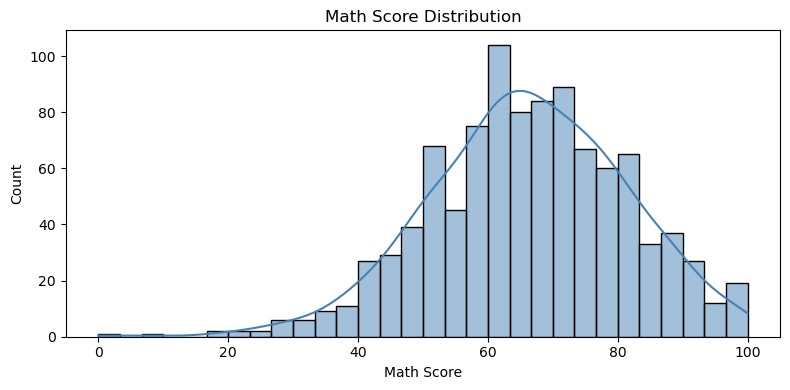

In [5]:
# Math score distribution
plt.figure(figsize=(8, 4))
sns.histplot(data['math score'], kde=True, color='steelblue', bins=30)
plt.title('Math Score Distribution')
plt.xlabel('Math Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_21376\167509910.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y='math score', data=data, palette='Set2')


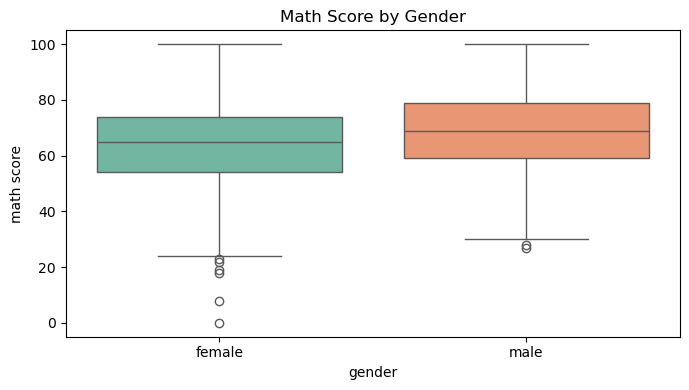

In [6]:
# Math score by gender
plt.figure(figsize=(7, 4))
sns.boxplot(x='gender', y='math score', data=data, palette='Set2')
plt.title('Math Score by Gender')
plt.tight_layout()
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_21376\2651676154.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='test preparation course', y='math score', data=data, palette='Set3')


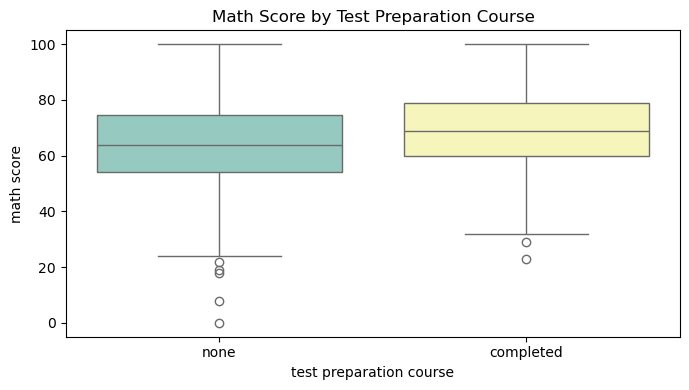

In [7]:
# Math score by test preparation course
plt.figure(figsize=(7, 4))
sns.boxplot(x='test preparation course', y='math score', data=data, palette='Set3')
plt.title('Math Score by Test Preparation Course')
plt.tight_layout()
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_21376\3728119853.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='parental level of education', y='math score',


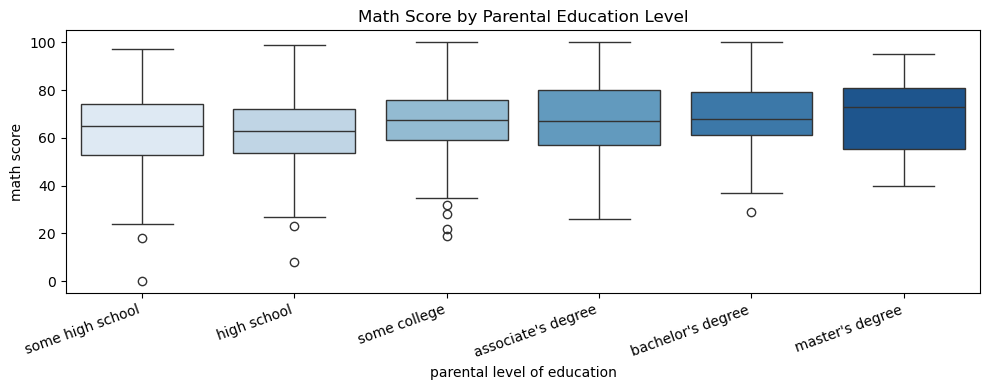

In [8]:
# Math score by parental education level
plt.figure(figsize=(10, 4))
order = ["some high school", "high school", "some college",
         "associate's degree", "bachelor's degree", "master's degree"]
sns.boxplot(x='parental level of education', y='math score',
            data=data, order=order, palette='Blues')
plt.title('Math Score by Parental Education Level')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## ✂️ 3. Split Data — Train & Test

In [9]:
target = 'math score'
X = data.drop(target, axis=1)
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train size: {X_train.shape[0]} samples')
print(f'Test size : {X_test.shape[0]} samples')

Train size: 800 samples
Test size : 200 samples


## 🔧 4. Build Pipeline

We handle **3 types of features**:

| Type | Features | Transformer |
|------|----------|-------------|
| Numerical | reading score, writing score | Imputer + StandardScaler |
| Ordinal | education level, gender, lunch, test prep | Imputer + OrdinalEncoder |
| Nominal | race/ethnicity | Imputer + OneHotEncoder |

In [10]:
# Define feature groups
num_features = ['reading score', 'writing score']
nom_features = ['race/ethnicity']
ord_features = ['parental level of education', 'gender', 'lunch', 'test preparation course']

# Ordinal categories (order matters for education level)
education_values = [
    'some high school', 'high school', 'some college',
    "associate's degree", "bachelor's degree", "master's degree"
]
gender_values  = X_train['gender'].unique().tolist()
lunch_values   = X_train['lunch'].unique().tolist()
test_prep_vals = X_train['test preparation course'].unique().tolist()

# Numerical pipeline
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Ordinal pipeline
ord_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[education_values, gender_values, lunch_values, test_prep_vals]
    ))
])

# Nominal pipeline
nom_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Combine all transformers
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('nom', nom_transformer, nom_features),
    ('ord', ord_transformer, ord_features),
])

# Full pipeline with model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

print('✅ Pipeline built successfully!')
print(pipeline)

✅ Pipeline built successfully!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['reading score',
                                                   'writing score']),
                                                 ('nom',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotE

## 🏋️ 5. Train Model

In [11]:
pipeline.fit(X_train, y_train)
print('✅ Model trained successfully!')

✅ Model trained successfully!


## 📊 6. Evaluate Model

In [12]:
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print('='*35)
print(f'  MAE  : {mae:.4f}')
print(f'  MSE  : {mse:.4f}')
print(f'  R²   : {r2:.4f}')
print('='*35)

  MAE  : 4.1820
  MSE  : 28.8211
  R²   : 0.8816


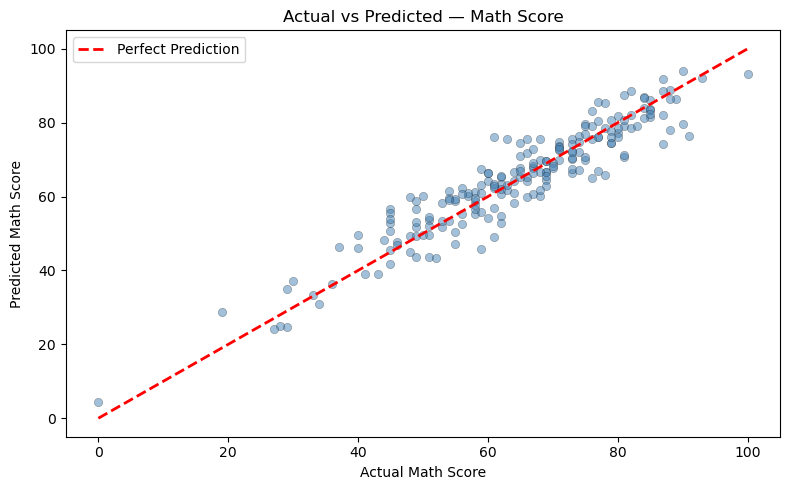

In [13]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Math Score')
plt.ylabel('Predicted Math Score')
plt.title('Actual vs Predicted — Math Score')
plt.legend()
plt.tight_layout()
plt.show()

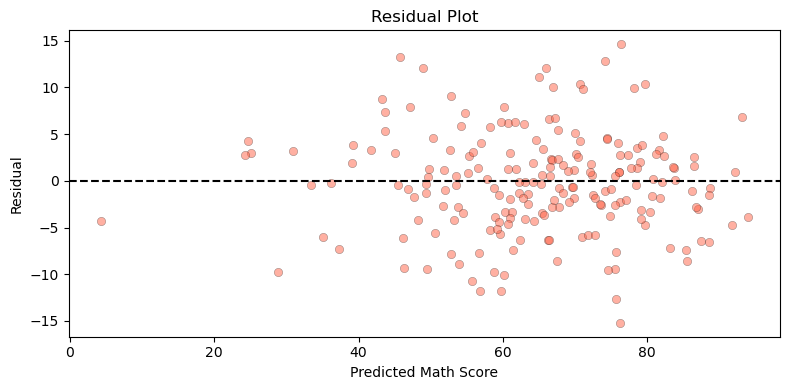

In [14]:
# Residuals plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuals, alpha=0.5, color='tomato', edgecolors='k', linewidths=0.3)
plt.axhline(0, color='black', linestyle='--', lw=1.5)
plt.xlabel('Predicted Math Score')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

In [15]:
# Sample predictions vs actual
comparison = pd.DataFrame({
    'Actual'   : y_test.values[:15],
    'Predicted': y_pred[:15].round(1),
    'Diff'     : (y_test.values[:15] - y_pred[:15]).round(1)
})
print('Sample Predictions vs Actual (first 15):')
print(comparison.to_string(index=False))

Sample Predictions vs Actual (first 15):
 Actual  Predicted  Diff
     91       76.4  14.6
     53       58.3  -5.3
     80       77.3   2.7
     74       76.3  -2.3
     84       87.1  -3.1
     81       79.0   2.0
     69       64.6   4.4
     54       53.5   0.5
     87       74.2  12.8
     51       49.7   1.3
     45       52.8  -7.8
     30       37.3  -7.3
     67       67.8  -0.8
     49       51.7  -2.7
     85       86.1  -1.1


## 🏁 7. Summary

| Item | Detail |
|------|--------|
| **Model** | Linear Regression |
| **Pipeline** | ColumnTransformer + sklearn Pipeline |
| **Numerical Features** | reading score, writing score |
| **Ordinal Features** | education level, gender, lunch, test prep |
| **Nominal Features** | race/ethnicity |

### 🔑 Key Takeaways
- ✅ **Reading & Writing scores** are the strongest predictors of math score
- ✅ **Test preparation course** completion positively impacts scores
- ✅ **Higher parental education** correlates with better student performance
- ✅ sklearn `Pipeline` ensures **no data leakage** between train and test sets
- ✅ `ColumnTransformer` handles different feature types cleanly in one step